In [ ]:
# # Install zstd first
# !apt-get update -qq
# !apt-get install -y zstd

# # Install Ollama
# !curl -fsSL https://ollama.com/install.sh | sh

# # Start Ollama server in the background
# import subprocess
# import time

# subprocess.Popen(["ollama", "serve"])
# time.sleep(5)

# # Pull the DeepSeek-R1 7B model
# !ollama pull deepseek-r1:7b

# print("✅ Ollama setup complete!")

# #for ollama use
# !pip install langchain_ollama
# !pip install langchain_community




In [ ]:
from langgraph.graph.state import Literal
from __future__ import annotations
from pydantic import BaseModel, Field
from typing import Annotated, List, TypedDict, Literal, Optional
from langchain_core.messages import SystemMessage, HumanMessage


from langchain_ollama import ChatOllama

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import operator

from langchain_community.tools.tavily_search import TavilySearchResults
from google.colab import userdata

In [ ]:
#@ Pydantic Functions:

#Task:
class Task(BaseModel):
    id: int
    title: str
    goal: str= Field(description="One liner description what the reader is able to do/understand after this section.")
    bullets: List[str]=Field(min_length=3,
                             max_length=5,
                             description="3-5 solid, non-overlapping subpoints to cover to this section")
    target_words: int=Field(description="Target word count for this section (120-400)")
    section_type: Literal["intro", "core","examples", "common_mistakes", "conclusion"]=Field(description="Use 'common_mistakes' once in the plan")
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False

#planner:
class Plan(BaseModel):
    blog_title:str
    audience: str=Field(description="To whom this blog is for")
    tone: str=Field(description="Tone of the blog")
    tasks:List[Task]


# Router:
class RouterDecision(BaseModel):
  needs_research: bool
  mode: Literal["closed_book", "hybrid", "open_book"]
  queries: List[str]= Field(default_factory=list)

#Evidence(Every researched items):
class EvidenceItem(BaseModel):
  title: str
  url: str
  published_at: Optional[str]=None
  snippet: Optional[str]=None
  source: Optional[str]=None

class EvidencePack(BaseModel):
 evidence: List[EvidenceItem]=Field(default_factory=list)


#state:
class State(TypedDict):
    topic: str

    #router/researcher
    mode: str
    need_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]

    #worker:
    sections: Annotated[List[str], operator.add] #esults from workers get automatically concatenated
    final: str


In [ ]:
llm=ChatOllama(model="deepseek-r1:7b")

In [ ]:
#@ System prompts for various nodes:

ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3–10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""

RESEARCH_PROMPT="""
You are research synthesizer for technical blog.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""


ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5–9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3–6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120–550)

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book:
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""

WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (±15%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard:
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URLs.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true:
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""


In [ ]:
#@ Router:
def router(state:State):
  topic=state['topic']
  decider=llm.with_structured_output(RouterDecision)
  decision=decider.invoke(
      SystemMessage(content=ROUTER_SYSTEM),
      HumanMessage(content=f"Topic: {topic}")
  )

  return {
      'needs_research': decision.needs_research,
      "mode": decision.mode,
      "queries": decision.queries
  }

def router_next(state: State):
  return "research" if state["needs_research"] else "ochestator"

In [ ]:
#@ tavily research for agent:

def _tavily_search(query:str, max_results: int = 5):
  tool= TavilySearchResults(max_results=max_results)
  result=tool.invoke({"query": query})

  normalized: List[dict] = []
  for r in result or []:
    normalized.append(
        {
            "title": r.get("title") or "",
            "url": r.get("url") or "",
            "snippet": r.get("snippet") or r.get("content") or "",
            "publised_at": r.get("published_date") or r.get("publised_at"),
            "source": r.get("source")
        }
    )
  return normalized


In [ ]:
#@ Research:
def research(state: State):
  queries=(state.get("queries", []) or [])
  max_result= 6 # for each query

  raw_results: List[dict] = []

  #searching each query:
  for q in queries:
   raw_results.extend(_tavily_search(q, max_results= max_result))

  #if empty result:
  if not raw_results:
    return {"evidence": []}

 #for structured searching:
  extractor = llm.with_structured_output(EvidencePack)
  pack= extractor.invoke(
      [
          SystemMessage(content=RESEARCH_PROMPT),
          HumanMessage(content=f'Raw result: \n {raw_results}')
      ]
  )

  #deduplicating URL:
  dedup={}
  for e in pack.evidence:
    if e.url:
      dedup[e.url]=e

  return {"evidence": list(dedup.values())}





In [ ]:
#@ Orchestrator(Planner):

def orchestator(state:State)->dict:
    planner=llm.with_structured_output(Plan)
    evidence=state.get("evidence", [])
    mode=state.get("mode", "closed_book")

    plan=planner.invoke(
        [
            SystemMessage(
                content=ORCH_SYSTEM
            ),

            HumanMessage(content=(f"Topic:{state['topic']}\n",
                                  f"Mode: {mode}\n",
                                  f"{[e.model_dump() for e in evidence][:16]}"))
        ]
    )

    return {'plan': plan}

- After the orchestrator node, system doesnt know how many workers do it need wrt to plan, so we need to built a fucntion which will trigger a worker for each plan/section

In [ ]:
def trigger(state: State):
  return [
      Send(
          "worker",
          {
              "task": task.model_dump(),
              "topic": state["topic"],
              "mode": state["mode"],
              "plan": state["plan"].model_dump(),
              "evidence": [e.model_dump() for e in state.get("evidence", [])],
          }
      ) for task in state['plan'].tasks
  ]

In [ ]:
#@ worker node:
def worker(payload:dict):

    #payoad contains what we send
    task=Task(**payload['task'])
    plan=Plan(**payload['plan'])
    topic = payload["topic"]
    mode= payload.get("mode", "closed_book")
    evidence=[EvidenceItem(**e) for e in payload.get("evidence", [])]

    blog_topic=plan.blog_title

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    section_md=llm.invoke(
        [
        SystemMessage(content=( )),
        HumanMessage(
            content=(
                f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n"
            )
        )]
    ).content.strip()

    return {"sections": [section_md]}

In [ ]:
from pathlib import Path

#@ Creating a reducer function:
def reducer(state:State):
    title=state['plan'].blog_title
    body= "\n\n".join(state['sections']).strip()

    final_md=f'# {title} \n\n {body}\n'


    #@ Saving md files:
    filename=title.lower().replace('' ,'_') + ".md"
    output_path=Path(filename)
    output_path.write_text(final_md, encoding='utf-8')

    return {"final": final_md}

In [ ]:
g=StateGraph(State)
g.add_node("router", router)
g.add_node("research", research)
g.add_node("orchestator", orchestator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

In [ ]:
g.add_edge(START, "router")
g.add_conditional_edges("router", router_next, {"research":"research", "orchestator": "Orchestator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", trigger, ['worker'])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

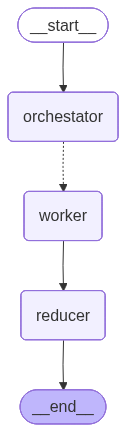

In [ ]:
app=g.compile()
app

In [ ]:
result=app.invoke({"topic": "write a blog on mountains", "sections":[]})
result

{'topic': 'write a blog on mountains',
 'plan': Plan(blog_title='How to Write a Technical Blog About Mountains', audience='Technical professionals seeking to write engaging technical content about mountains.', tone='Professional and insightful, balancing code examples with real-world insights.', tasks=[Task(id=1, title='Set the Stage', goal='Introduce the importance of a well-crafted technical blog on mountain topics to your audience.', bullets=['Explain why technical blogging about mountains is valuable.', 'Highlight how mountain themes can inform and inspire technical writing practices.', 'Outline the unique opportunities for technical exploration in mountain environments.'], target_words=150, section_type='common_mistakes'), Task(id=2, title='Choose Your Mountain Technology Stack', goal='Guide readers in selecting the best platforms and tools for their mountain-themed technical content.', bullets=['Compare static site generators like Jekyll or Gatsby with custom CMS solutions.', 'Re